In [ ]:
# 1. Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. Giải nén file dataset từ Drive vào bộ nhớ tạm của Colab
# Giả sử file zip nằm ngay ở thư mục gốc của MyDrive
!unzip -q /content/drive/MyDrive/Color_Vehicle.zip -d /content/dataset_yolo
print("✅ Đã giải nén dataset thành công vào thư mục /content/dataset_yolo")

✅ Đã giải nén dataset thành công vào thư mục /content/dataset_yolo


In [ ]:
!pip install ultralytics pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.7 MB/s eta 0:00:00


In [ ]:
# =====================================================================
# KỊCH BẢN HUẤN LUYỆN TỰ ĐỘNG 4 PHIÊN BẢN YOLOv8 (TRAIN SCRIPT)
# =====================================================================
!pip install ultralytics -q

import os
import torch
from ultralytics import YOLO

# 1. Đường dẫn tới file cấu hình bộ dữ liệu của bạn
data_yaml_path = "/content/dataset_yolo/data.yaml"

# 2. Cấu hình tham số huấn luyện (Bạn có thể tùy chỉnh lại theo nhu cầu)
EPOCHS = 30         # Số lượng kỷ nguyên train (Ví dụ: 30, 50, 100...)
BATCH_SIZE = 16     # Kích thước Batch (Nếu chạy bản 'l' bị tràn bộ nhớ GPU, code sẽ tự động hạ xuống)
IMAGE_SIZE = 640    # Kích thước ảnh đầu vào chuẩn của YOLOv8

# Kiểm tra môi trường GPU
device_target = 0 if torch.cuda.is_available() else "cpu"
print(f"🎯 Thiết bị sử dụng để huấn luyện: {device_target}")
if device_target == "cpu":
    print("⚠️ Cảnh báo: Đang chạy bằng CPU, tốc độ train sẽ rất chậm. Nên bật GPU T4!")

# Danh sách cấu hình tương ứng: { "Tên_Mode": "File_Trọng_Số_Gốc" }
yolo_modes = {
    "train_n": "yolov8n.pt",
    "train_s": "yolov8s.pt",
    "train_m": "yolov8m.pt",
    "train_l": "yolov8l.pt"
}

print("\n" + "="*20 + " BẮT ĐẦU CHU KỲ HUẤN LUYỆN 4 MODES " + "="*20)

# 3. Vòng lặp tự động huấn luyện lần lượt từng mô hình
for mode_name, base_weight in yolo_modes.items():
    print(f"\n🚀 [MODE: {mode_name.upper()}] Đang khởi tạo mô hình nền tảng: {base_weight}")

    # Tải trọng số gốc từ máy chủ Ultralytics
    model = YOLO(base_weight)

    # Thiết lập Batch Size an toàn cho phiên bản lớn để tránh lỗi Out Of Memory (OOM)
    current_batch = BATCH_SIZE
    if mode_name == "train_l" and device_target == 0:
        current_batch = 8 # Hạ batch size xuống 8 đối với bản Large trên GPU T4 cho an toàn
        print(f"   -> Tự động điều chỉnh Batch Size xuống {current_batch} cho phiên bản YOLOv8l để tránh tràn bộ nhớ.")

    print(f"⚙️ Đang tiến hành huấn luyện mô hình với cấu hình: Epochs={EPOCHS}, Batch={current_batch}...")

    # Kích hoạt tiến trình Train
    model.train(
        data=data_yaml_path,
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE,
        batch=current_batch,
        device=device_target,
        project="/content/runs/detect", # Thư mục dự án tổng
        name=mode_name,                 # Tên thư mục con (Sẽ tạo ra: train_n, train_s...)
        exist_ok=True,                  # Ghi đè/tiếp tục nếu thư mục đã tồn tại
        verbose=True
    )

    # Xác nhận vị trí lưu file weights sau khi kết thúc chu kỳ train của mode đó
    expected_best_path = f"/content/runs/detect/{mode_name}/weights/best.pt"
    if os.path.exists(expected_best_path):
        print(f"✅ Huấn luyện thành công {mode_name.upper()}! Trọng số tối ưu lưu tại: {expected_best_path}")
    else:
        print(f"❌ Có lỗi xảy ra, không tìm thấy file best.pt của {mode_name}")

print("\n" + "="*20 + " HOÀN THÀNH TOÀN BỘ QUY TRÌNH HUẤN LUYỆN 4 MODES " + "="*20)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🎯 Thiết bị sử dụng để huấn luyện: 0

==================== BẮT ĐẦU CHU KỲ HUẤN LUYỆN 4 MODES ====================

🚀 [MODE: TRAIN_N] Đang khởi tạo mô hình nền tảng: yolov8n.pt
⚙️ Đang tiến hành huấn luyện mô hình với cấu hình: Epochs=30, Batch=16...
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo/data.yaml, degrees=0.0, deterministic=T

🎯 Thiết bị phần cứng đang sử dụng: GPU (0)

==================== BẮT ĐẦU ĐÁNH GIÁ CHỈ SỐ THỰC NGHIỆM ====================

--> Đang tải trọng số đã train: /content/runs/detect/train_n/weights/best.pt
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1539.2±319.6 MB/s, size: 80.1 KB)
val: Scanning /content/dataset_yolo/test/labels.cache... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 11.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.6s
                   all         55        657       0.87      0.815      0.896      0.679
Speed: 16.2ms preprocess, 8.8ms inference, 0.0ms loss, 6.2ms postprocess per image
Results saved to /content/runs/detect/val-2
   [Tốc độ] Đã xử lý 55 ảnh trong 0.67 giây.

--> Đang tải trọng số đã train: /

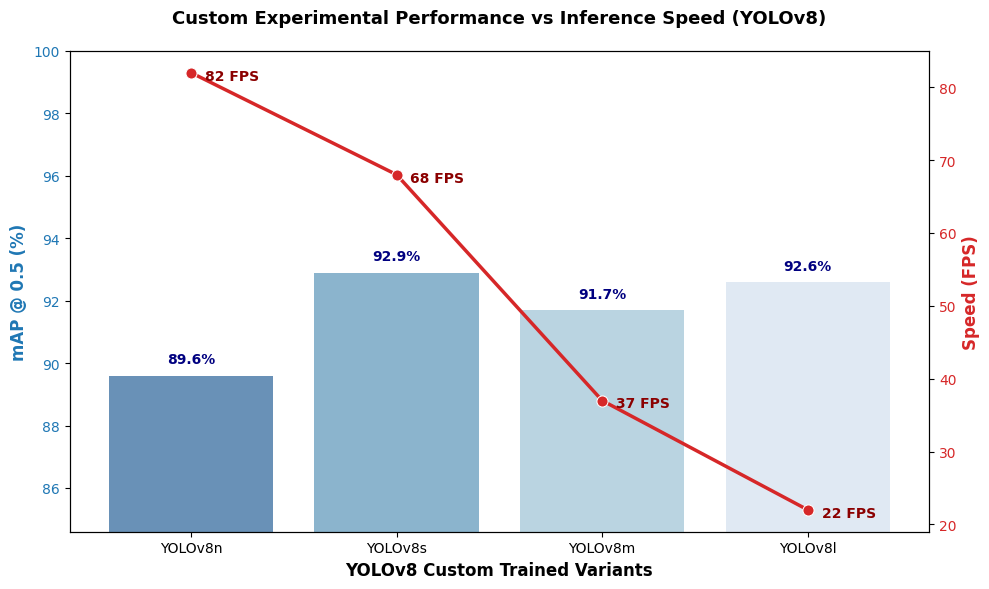

In [ ]:
import os
import time
import glob
import torch
import yaml  # Dùng để đọc file cấu hình data.yaml một cách chuẩn xác
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# =====================================================================
# CẤU HÌNH ĐƯỜNG DẪN ĐẾN CÁC FILE BEST.PT THEO SƠ ĐỒ CỦA BẠN
# =====================================================================
data_yaml_path = "/content/dataset_yolo/data.yaml"

# Khai báo chính xác vị trí lưu file best.pt của từng phiên bản sau khi bạn train xong
model_paths = {
    "YOLOv8n (Custom)": "/content/runs/detect/train_n/weights/best.pt",
    "YOLOv8s (Custom)": "/content/runs/detect/train_s/weights/best.pt",
    "YOLOv8m (Custom)": "/content/runs/detect/train_m/weights/best.pt",
    "YOLOv8l (Custom)": "/content/runs/detect/train_l/weights/best.pt"
}

# Tự động cấu hình thiết bị (Ưu tiên GPU để đo FPS thực nghiệm chuẩn xác)
device_target = 0 if torch.cuda.is_available() else "cpu"
print(f"🎯 Thiết bị phần cứng đang sử dụng: {device_target.upper() if isinstance(device_target, str) else 'GPU (0)'}")

# Đọc file data.yaml để xác định chính xác thư mục chứa ảnh test/val
dataset_root = os.path.dirname(data_yaml_path)
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Lấy đường dẫn tập test, nếu không có thì lấy tập val
sub_dir = data_config.get('test', data_config.get('val', 'test/images'))
# Khắc phục trường hợp đường dẫn trong file yaml chứa dấu chấm dẫn đường kiểu "../test/images"
sub_dir = sub_dir.replace('../', '')

test_image_dir = os.path.join(dataset_root, sub_dir)
image_paths = glob.glob(os.path.join(test_image_dir, "*.jpg")) + glob.glob(os.path.join(test_image_dir, "*.png"))

# Lấy tối đa 500 ảnh để chạy benchmark tốc độ FPS
image_paths = image_paths[:500]
num_images = len(image_paths)

experimental_results = []

# =====================================================================
# VÒNG LẶP ĐÁNH GIÁ TỪNG FILE "BEST.PT" THEO MÔ HÌNH THỰC NGHIỆM
# =====================================================================
print("\n" + "="*20 + " BẮT ĐẦU ĐÁNH GIÁ CHỈ SỐ THỰC NGHIỆM " + "="*20)

for model_name, path in model_paths.items():
    if not os.path.exists(path):
        print(f"⚠️ Bỏ qua {model_name}: Không tìm thấy file weights tại đường dẫn '{path}'")
        continue

    print(f"\n--> Đang tải trọng số đã train: {path}")
    model = YOLO(path)

    # -----------------------------------------------------------------
    # BƯỚC 3: Trích xuất chỉ số từ file best.pt bằng hàm .val()
    # -----------------------------------------------------------------
    # Thử chạy trên tập test trước, nếu lỗi tập test thì tự chuyển qua tập val
    try:
        metrics = model.val(data=data_yaml_path, split='test', verbose=False, device=device_target)
    except Exception:
        metrics = model.val(data=data_yaml_path, split='val', verbose=False, device=device_target)

    map50 = metrics.results_dict.get('metrics/mAP50(B)', 0) * 100
    map50_95 = metrics.results_dict.get('metrics/mAP50-95(B)', 0) * 100
    precision = metrics.results_dict.get('metrics/precision(B)', 0) * 100
    recall = metrics.results_dict.get('metrics/recall(B)', 0) * 100

    # -----------------------------------------------------------------
    # BƯỚC 4: Đo tốc độ Inference bằng time.perf_counter() độc lập
    # -----------------------------------------------------------------
    if num_images == 0:
        print(f"⚠️ Không tìm thấy ảnh trong thư mục '{test_image_dir}' để đo FPS.")
        fps = 0
    else:
        # Chạy khởi động (Warm-up) 3 ảnh để tăng độ chính xác tính toán của phần cứng
        for warm_img in image_paths[:3]:
            _ = model.predict(warm_img, verbose=False, device=device_target)

        # Bấm giờ thực tế
        start_time = time.perf_counter()
        for img_p in image_paths:
            _ = model.predict(img_p, verbose=False, device=device_target)
        end_time = time.perf_counter()

        total_time = end_time - start_time
        fps = int(num_images / total_time) if total_time > 0 else 0
        print(f"   [Tốc độ] Đã xử lý {num_images} ảnh trong {total_time:.2f} giây.")

    # Lưu dữ liệu vào bảng kết quả tổng hợp
    experimental_results.append({
        "Model": model_name.replace(" (Custom)", ""),
        "mAP@0.5 (%)": round(map50, 1),
        "mAP@0.5:0.95 (%)": round(map50_95, 1),
        "Precision (%)": round(precision, 1),
        "Recall (%)": round(recall, 1),
        "FPS": fps
    })

# =====================================================================
# BƯỚC 5: XUẤT BẢNG SO SÁNH VÀ ĐỒ THỊ BÁO CÁO
# =====================================================================
df_results = pd.DataFrame(experimental_results)

print("\n" + "="*15 + " TABLE 1: EXPERIMENTAL VEHICLE DETECTION PERFORMANCE " + "="*15)
print(df_results.to_string(index=False))
print("="*82 + "\n")

# Tiến hành vẽ biểu đồ trực quan hóa dữ liệu thực nghiệm
if not df_results.empty:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('YOLOv8 Custom Trained Variants', fontweight='bold', fontsize=12)
    ax1.set_ylabel('mAP @ 0.5 (%)', color=color, fontweight='bold', fontsize=12)
    sns.barplot(x='Model', y='mAP@0.5 (%)', data=df_results, ax=ax1, hue='Model', palette='Blues_r', alpha=0.7, legend=False)
    ax1.tick_params(axis='y', labelcolor=color)

    min_map = df_results['mAP@0.5 (%)'].min()
    ax1.set_ylim(max(0, min_map - 5), 100)

    for p in ax1.patches:
        ax1.annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold', color='navy')

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Speed (FPS)', color=color, fontweight='bold', fontsize=12)
    sns.lineplot(x='Model', y='FPS', data=df_results, ax=ax2, color=color, marker='o', linewidth=2.5, markersize=8)
    ax2.tick_params(axis='y', labelcolor=color)

    for i, txt in enumerate(df_results['FPS']):
        ax2.annotate(f"{txt} FPS", (df_results['Model'][i], df_results['FPS'][i]),
                    textcoords="offset points", xytext=(10,-5), ha='left', color='darkred', fontweight='bold')

    plt.title('Custom Experimental Performance vs Inference Speed (YOLOv8)', fontsize=13, fontweight='bold', pad=20)
    fig.tight_layout()
    plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Khởi tạo và đường dẫn tới Model YOLOv8l Custom của bạn
path_to_model = "/content/runs/detect/train_l/weights/best.pt"
model = YOLO(path_to_model)

# 2. Đường dẫn tới bức ảnh bạn muốn kiểm tra
image_path = "/content/4.jpg"

# Đọc ảnh gốc bằng OpenCV
img = cv2.imread(image_path)
if img is None:
    print(f"Không tìm thấy ảnh tại: {image_path}")
    exit()

# 3. Tiến hành dự đoán với ngưỡng tự tin (conf) = 0.25
results = model.predict(source=image_path, conf=0.25, verbose=False)

# 4. Duyệt qua kết quả để vẽ khung và hiển thị loại xe
for r in results:
    for box in r.boxes:
        # Lấy ID của class và chuyển sang tên loại xe đã cấu hình khi train
        cls_id = int(box.cls[0])
        class_name = model.names[cls_id]

        # Lấy độ tự tin (Confidence)
        conf = float(box.conf[0])

        # Lấy tọa độ bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Vẽ khung hình chữ nhật bao quanh xe (Màu xanh lá - BGR: 0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Định dạng chuỗi hiển thị: "Tên_Xe Độ_Tự_Tin%"
        label_text = f"{class_name} {conf*100:.1f}%"

        # Cấu hình font chữ hiển thị
        font_face = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2

        # Tính toán kích thước khối text để làm nền màu trắng
        (tw, th), base_line = cv2.getTextSize(label_text, font_face, font_scale, thickness)

        # Xử lý nếu vị trí chữ bị vượt quá mép trên của bức ảnh
        text_y = y1 - 5
        if text_y < th:
            text_y = y2 + th + 5

        # Vẽ nền nhãn màu TRẮNG (đầy khối: -1)
        cv2.rectangle(
            img,
            (x1, text_y - th - 5),
            (x1 + tw + 5, text_y + base_line - 3),
            (255, 255, 255),
            -1
        )

        # Viết chữ loại xe màu ĐEN lên nền trắng
        cv2.putText(
            img,
            label_text,
            (x1 + 3, text_y - 2),
            font_face,
            font_scale,
            (0, 0, 0),
            thickness,
            lineType=cv2.LINE_AA
        )

        # In thông báo log ra console để theo dõi
        print(f"Phát hiện: {class_name} ({conf*100:.2f}%) tại vị trí [{x1}, {y1}, {x2}, {y2}]")

# 5. Hiển thị ảnh kết quả trực quan lên màn hình Colab
plt.figure(figsize=(12, 9))
# Chuyển đổi hệ màu từ BGR (OpenCV) sang RGB (Matplotlib) để không bị sai lệch màu
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off") # Tắt thanh tọa độ x-y
plt.title(f"Kết quả nhận diện loại xe với YOLOv8l (Custom)", fontsize=14, fontweight='bold')
plt.show()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/train_l/weights/best.pt'